<a href="https://colab.research.google.com/github/theafzalansari/seasonal-agriculture-performance-analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

### Major Project – Data Visualization

**Objective:**  
To analyze agricultural data across different seasons and identify meaningful
patterns, trends, relationships and variations in agricultural performance.

**Dataset:** Seasonal Agriculture Performance Dataset

In [7]:
# ============================================================
# SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# CELL 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")

# Load dataset
file_path = "/content/seasonal_agriculture_performance_dataset (1).csv"

df = pd.read_csv(file_path)

print("=" * 60)
print("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("=" * 60)

print(f"\nDataset loaded successfully.")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

print("\nFirst 5 records:")
display(df.head())

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS

Dataset loaded successfully.
Number of rows    : 4000
Number of columns : 28

First 5 records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
# ============================================================
# CELL 2: DATA UNDERSTANDING AND CLEANING
# ============================================================

print("DATASET INFORMATION")
print("=" * 60)

print("\nData Types:")
df.info()

print("\n\nMissing Values:")
missing = df.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

# ------------------------------------------------------------
# CLEANING
# ------------------------------------------------------------

df_clean = df.copy()

# Numerical columns with missing values
numeric_missing_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

# Fill missing values using median
for column in numeric_missing_columns:
    if column in df_clean.columns:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

# Remove duplicate rows
duplicates_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

# Create derived variables
df_clean["Profit_Margin_pct"] = (
    df_clean["Profit_INR"] /
    df_clean["Revenue_INR"]
) * 100

df_clean["Cost_per_Tonne_INR"] = (
    df_clean["Total_Cost_INR"] /
    df_clean["Production_Tonnes"]
)

df_clean["Revenue_per_Hectare_INR"] = (
    df_clean["Revenue_INR"] /
    df_clean["Farm_Area_Hectares"]
)

df_clean["Profit_per_Hectare_INR"] = (
    df_clean["Profit_INR"] /
    df_clean["Farm_Area_Hectares"]
)

print("\n" + "=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)

print("Rows before cleaning       :", len(df))
print("Duplicate rows removed     :", duplicates_removed)
print("Rows after cleaning        :", len(df_clean))
print(
    "Remaining missing values   :",
    df_clean.isnull().sum().sum()
)

print("\nCleaned dataset:")
display(df_clean.head())

DATASET INFORMATION

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha 

,Missing Values,Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80



Duplicate Rows: 0

CLEANING SUMMARY
Rows before cleaning       : 4000
Duplicate rows removed     : 0
Rows after cleaning        : 4000
Remaining missing values   : 0

Cleaned dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Tonne_INR,Revenue_per_Hectare_INR,Profit_per_Hectare_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"32,816.92","58,132.08","-22,362.26"
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","251,199.49","6,186.98","-69,211.33"
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"124,588.93","39,190.53","-25,667.49"
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"35,802.42","44,608.89","-21,267.56"
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"36,339.68","45,987.41","-34,287.89"


EXPLORATORY DATA ANALYSIS

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00



CATEGORICAL VARIABLE DISTRIBUTION

State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


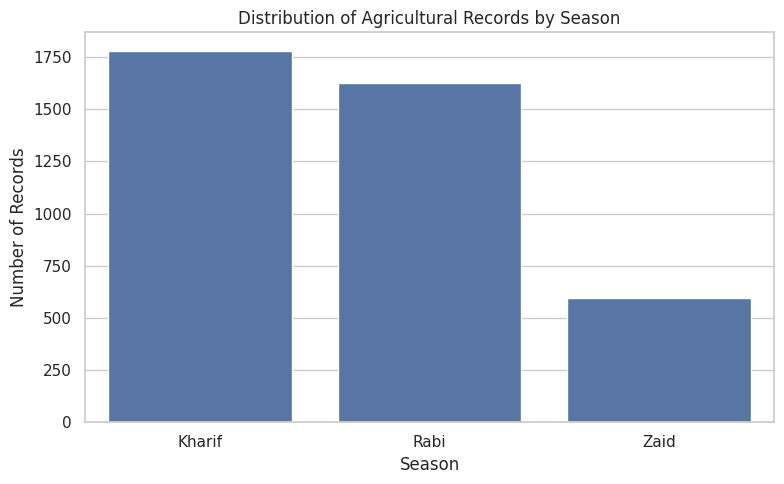

In [9]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Numerical summary
print("\nSTATISTICAL SUMMARY")
display(df_clean.describe().T)

# Categorical variables
categorical_columns = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

print("\nCATEGORICAL VARIABLE DISTRIBUTION")

for column in categorical_columns:
    print(f"\n{column}:")
    print(df_clean[column].value_counts())

# Season distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Season",
    order=df_clean["Season"].value_counts().index
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

SEASONAL AGRICULTURAL PERFORMANCE


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


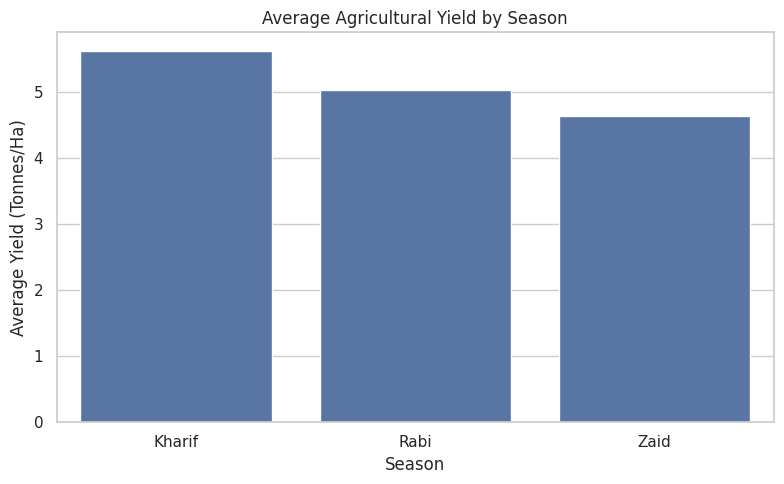

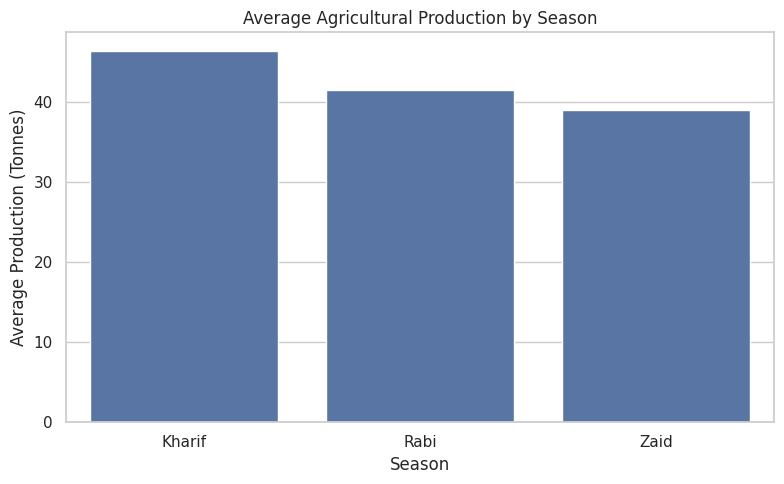

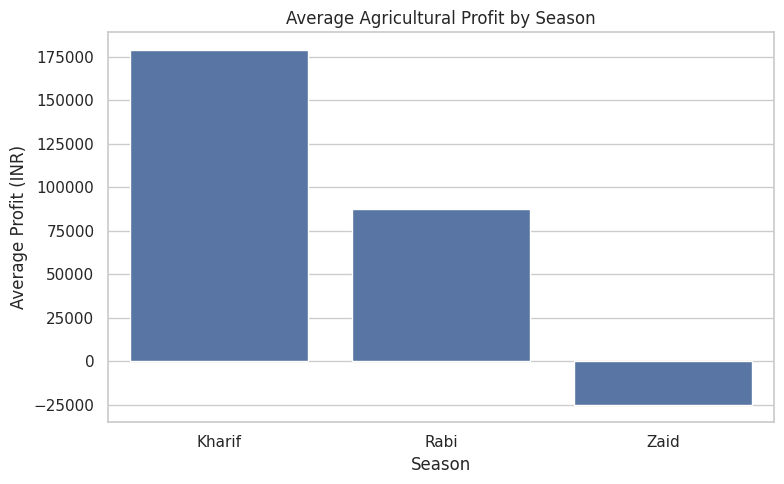

In [10]:
# ============================================================
# CELL 4: SEASONAL AGRICULTURAL PERFORMANCE
# ============================================================

print("=" * 60)
print("SEASONAL AGRICULTURAL PERFORMANCE")
print("=" * 60)

season_performance = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

display(season_performance)

# ------------------------------------------------------------
# YIELD
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PRODUCTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Production_Tonnes",
    estimator="mean",
    errorbar=None
)

plt.title("Average Agricultural Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PROFIT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None
)

plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

ENVIRONMENTAL CONDITIONS BY SEASON


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,6.73
Rabi,437.62,23.49,57.89,7.59,24.07,6.67
Zaid,304.65,31.04,52.01,8.18,19.28,6.69


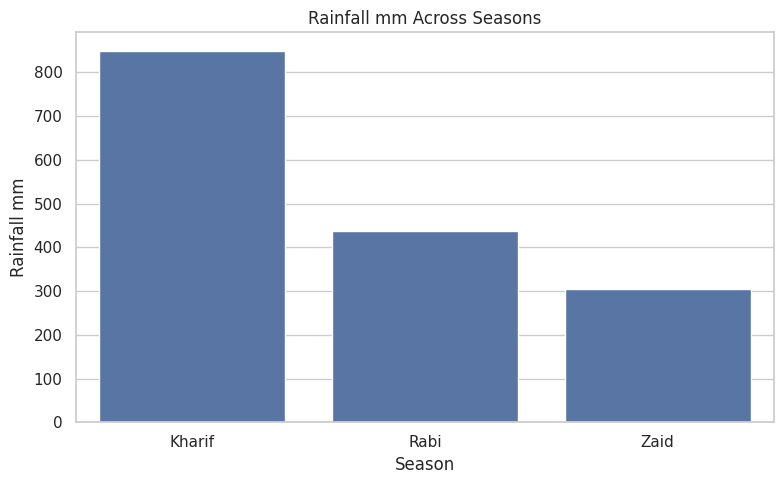

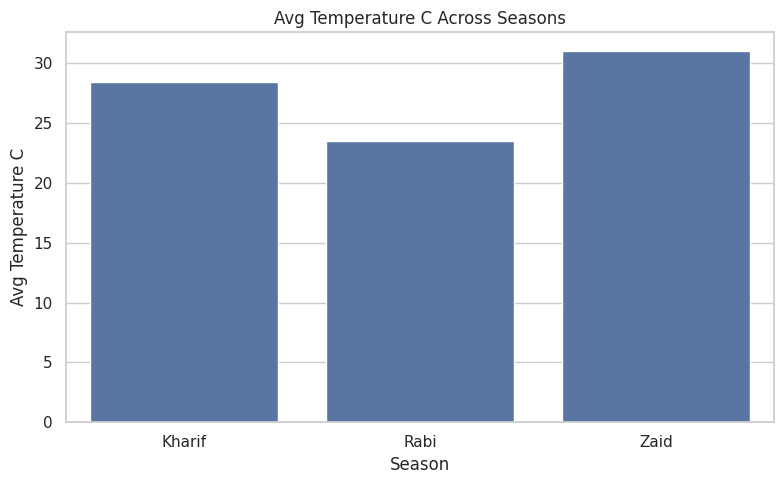

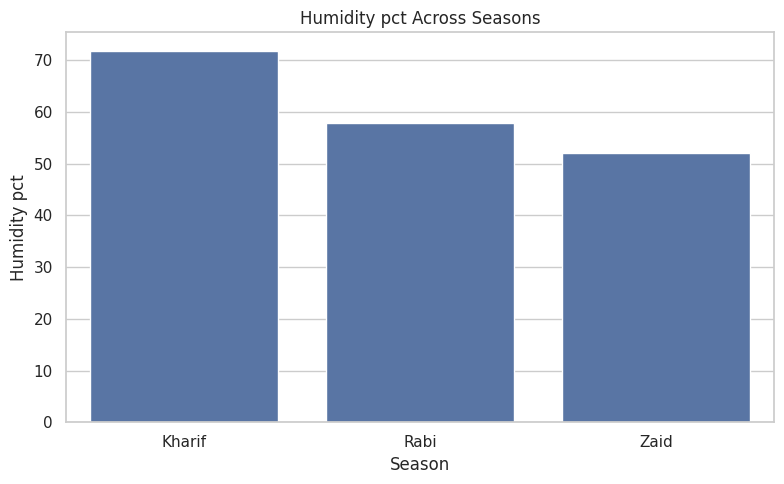

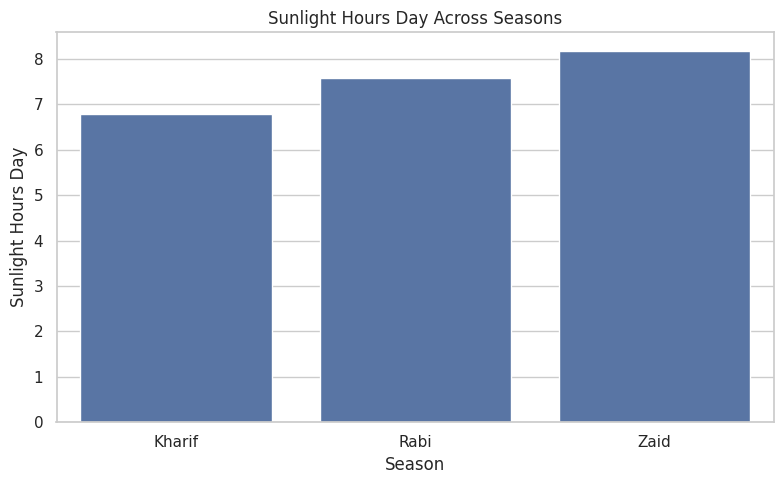

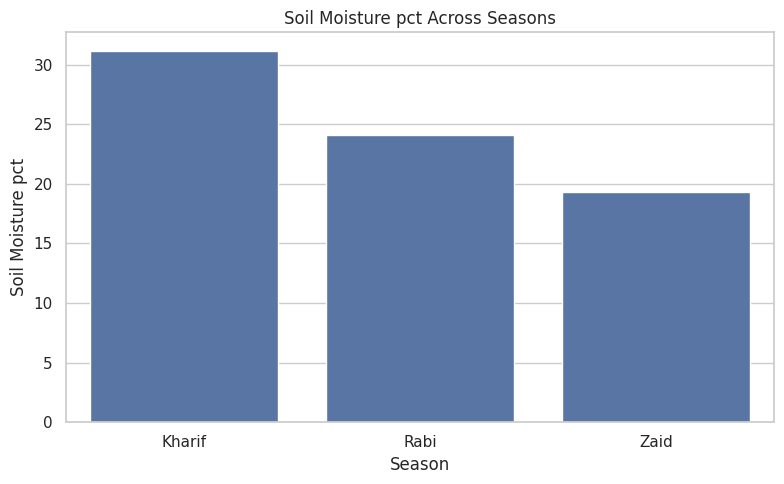

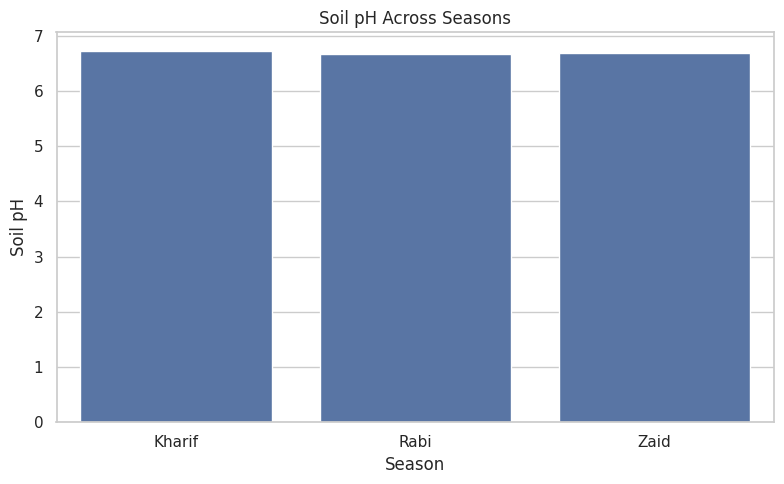

In [11]:
# ============================================================
# CELL 5: ENVIRONMENTAL CONDITIONS BY SEASON
# ============================================================

print("=" * 60)
print("ENVIRONMENTAL CONDITIONS BY SEASON")
print("=" * 60)

environmental_variables = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Soil_pH"
]

environmental_summary = df_clean.groupby("Season")[
    environmental_variables
].mean().round(2)

display(environmental_summary)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

for variable in environmental_variables:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_clean,
        x="Season",
        y=variable,
        estimator="mean",
        errorbar=None
    )

    plt.title(
        f"{variable.replace('_', ' ')} Across Seasons"
    )

    plt.xlabel("Season")
    plt.ylabel(variable.replace("_", " "))

    plt.tight_layout()
    plt.show()

RESOURCE USAGE BY SEASON


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20"
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99"
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89"


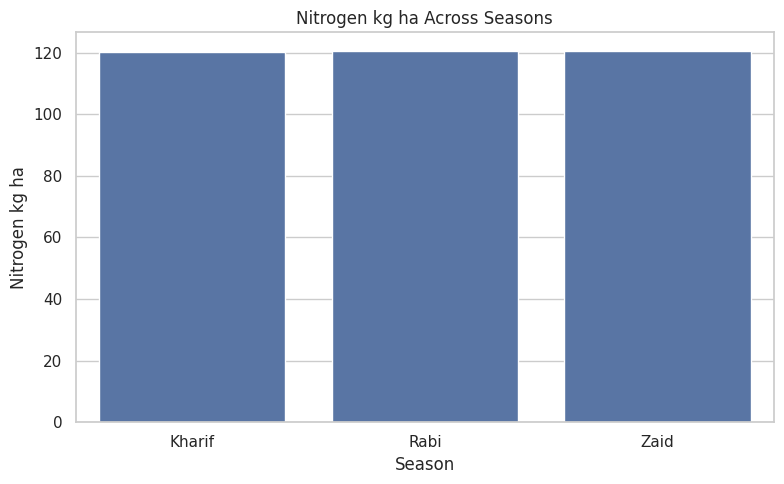

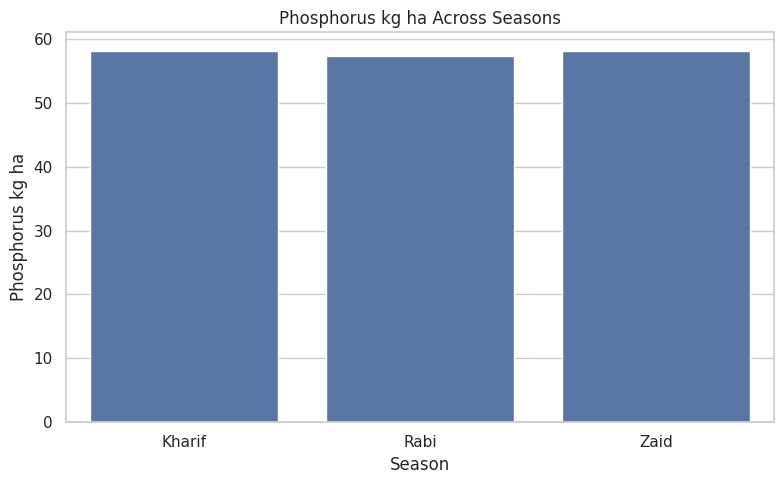

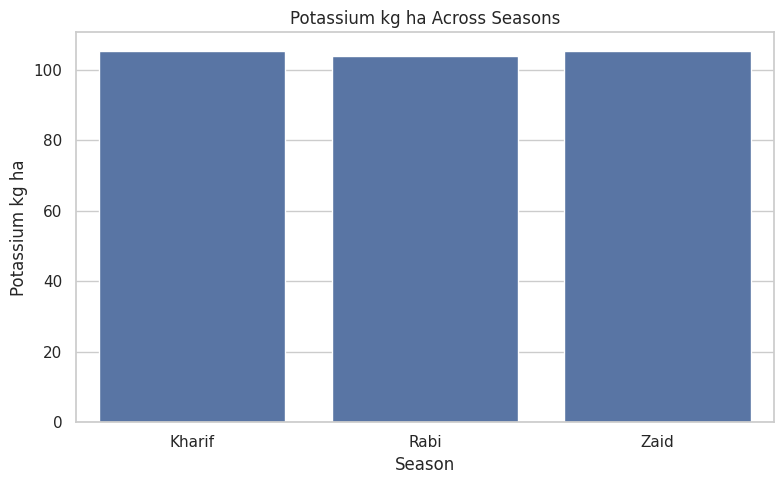

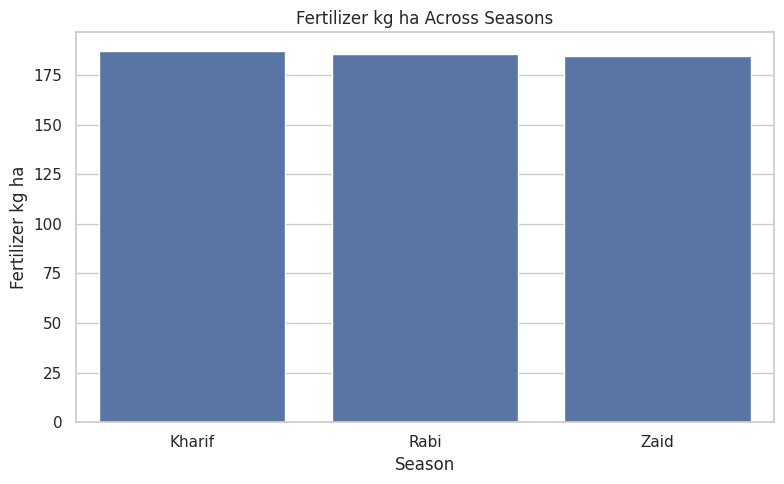

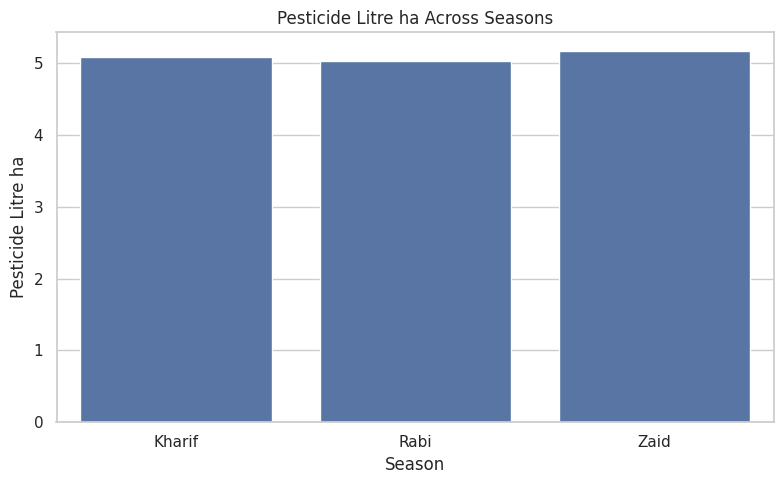

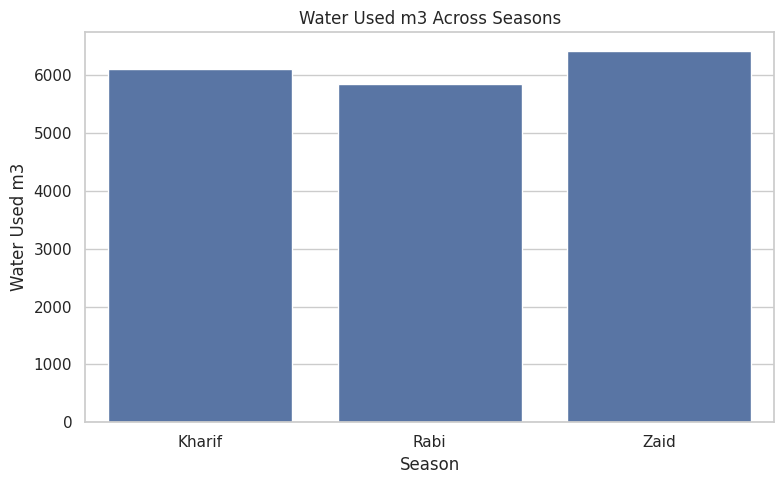

In [12]:
# ============================================================
# CELL 6: RESOURCE USAGE BY SEASON
# ============================================================

print("=" * 60)
print("RESOURCE USAGE BY SEASON")
print("=" * 60)

resource_variables = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3"
]

resource_summary = df_clean.groupby("Season")[
    resource_variables
].mean().round(2)

display(resource_summary)

# ------------------------------------------------------------
# RESOURCE VISUALIZATIONS
# ------------------------------------------------------------

for variable in resource_variables:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_clean,
        x="Season",
        y=variable,
        estimator="mean",
        errorbar=None
    )

    plt.title(
        f"{variable.replace('_', ' ')} Across Seasons"
    )

    plt.xlabel("Season")
    plt.ylabel(variable.replace("_", " "))

    plt.tight_layout()
    plt.show()

CROP-WISE SEASONAL PERFORMANCE

Overall Crop Performance:


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Crop,,,,,,
Sugarcane,46.64,392.41,"1,371,980.11","817,187.99",30.48,45.40
Maize,2.71,21.78,"457,067.99","-83,978.33",5.60,45.54
Rice,2.43,19.29,"423,615.26","-102,213.50",1.95,46.50
Wheat,2.11,16.85,"400,104.89","-123,398.34",4.63,47.85
Chilli,1.54,12.38,"1,276,777.23","750,878.34",2.95,46.06
Groundnut,1.32,9.66,"542,935.50","44,858.12",3.15,46.29
Cotton,1.23,9.40,"639,423.08","124,546.92",1.94,45.97
Pulses,0.92,7.40,"528,465.87","-4,238.05",2.90,46.57



Average Yield by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


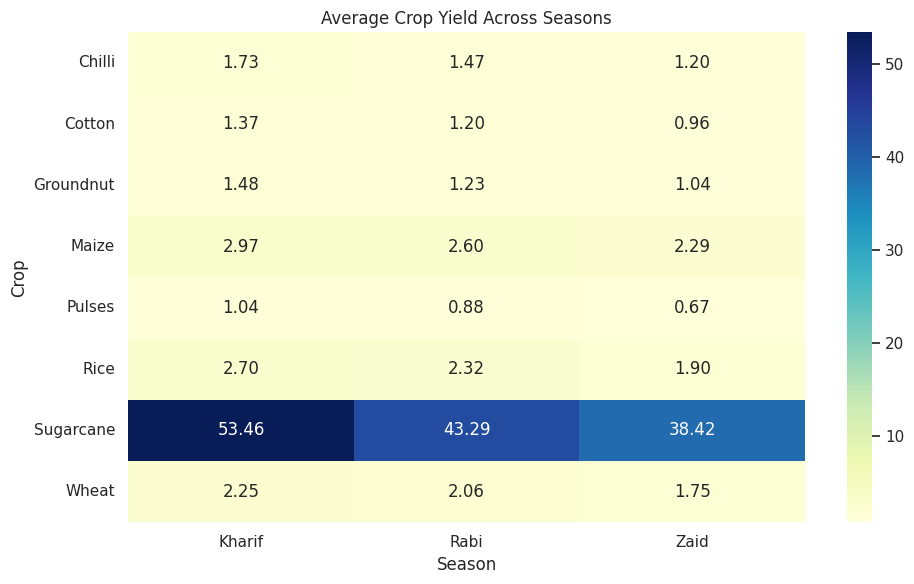


Average Profit by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.42","638,572.50","448,659.09"
Cotton,"216,999.55","107,343.59","-53,925.34"
Groundnut,"108,265.44","10,416.54","-68,872.50"
Maize,"-39,332.67","-89,133.40","-194,049.17"
Pulses,"43,338.90","-14,309.14","-139,227.81"
Rice,"-64,903.40","-98,427.87","-227,239.34"
Sugarcane,"1,000,790.81","731,612.86","583,635.80"
Wheat,"-105,871.87","-119,954.57","-193,208.95"


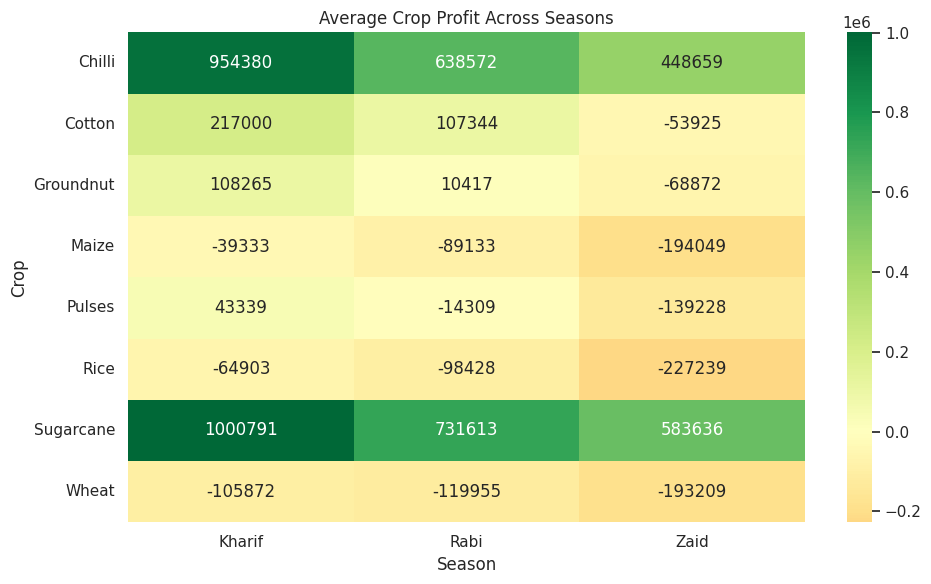

In [13]:
# ============================================================
# CELL 7: CROP AND SEASON ANALYSIS
# ============================================================

print("=" * 60)
print("CROP-WISE SEASONAL PERFORMANCE")
print("=" * 60)

# Crop performance
crop_performance = df_clean.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
).round(2)

print("\nOverall Crop Performance:")
display(crop_performance)

# ------------------------------------------------------------
# CROP × SEASON YIELD
# ------------------------------------------------------------

crop_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

print("\nAverage Yield by Crop and Season:")
display(crop_season_yield.round(2))

plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CROP × SEASON PROFIT
# ------------------------------------------------------------

crop_season_profit = pd.pivot_table(
    df_clean,
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

print("\nAverage Profit by Crop and Season:")
display(crop_season_profit.round(2))

plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

STATE-WISE AGRICULTURAL PERFORMANCE


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
State,,,,,
Punjab,6.12,52.23,"686,225.70","136,025.64",5.62
Karnataka,5.69,47.73,"653,426.18","119,422.34",5.56
Gujarat,5.66,48.33,"654,692.86","117,568.24",5.58
Telangana,5.04,39.25,"628,784.53","108,829.62",5.46
Maharashtra,5.02,43.98,"650,032.67","135,428.86",5.28
Madhya Pradesh,4.99,37.56,"597,558.36","86,840.76",5.27
Tamil Nadu,4.88,40.84,"629,093.42","117,744.75",5.31
Andhra Pradesh,4.63,36.91,"606,663.66","73,453.53",5.03


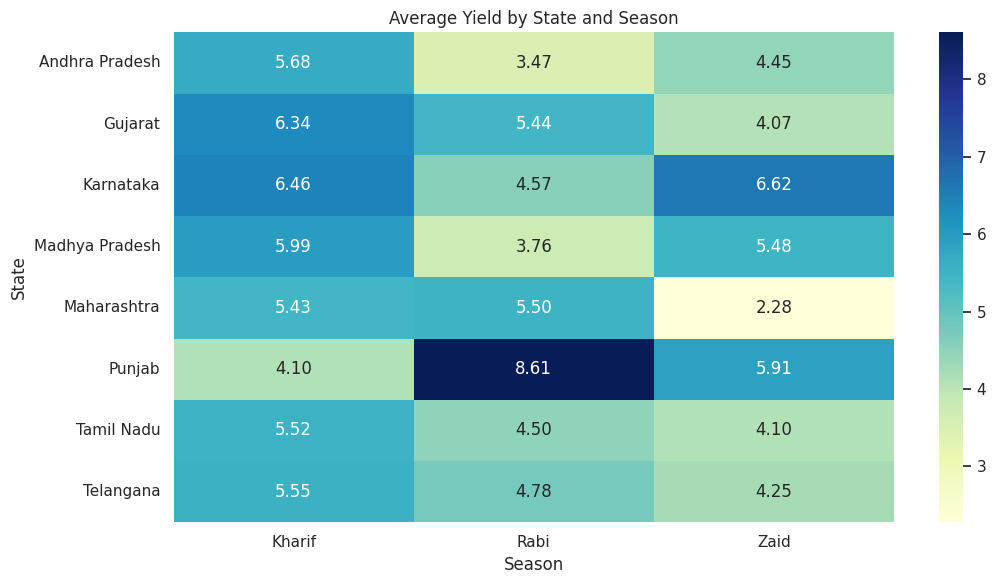


IRRIGATION METHOD PERFORMANCE


,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.58,"219,626.00","5,918.75",6.27
Sprinkler,5.16,"91,121.08","6,208.26",4.67
Flood,4.86,"73,354.02","8,026.47",3.44
Rainfed,4.60,"79,050.37","3,549.55",7.56


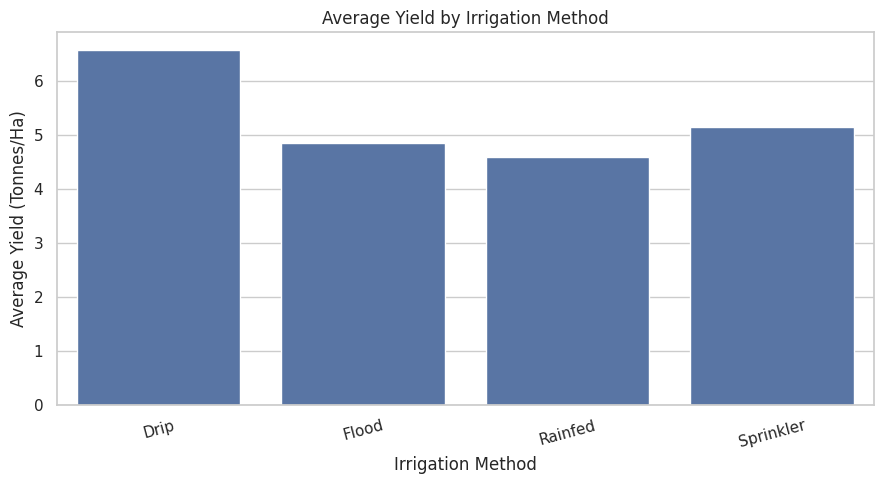

In [14]:
# ============================================================
# CELL 8: STATE AND IRRIGATION ANALYSIS
# ============================================================

print("=" * 60)
print("STATE-WISE AGRICULTURAL PERFORMANCE")
print("=" * 60)

state_performance = df_clean.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
).round(2)

display(state_performance)

# ------------------------------------------------------------
# STATE × SEASON YIELD
# ------------------------------------------------------------

state_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# IRRIGATION ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IRRIGATION METHOD PERFORMANCE")
print("=" * 60)

irrigation_performance = df_clean.groupby(
    "Irrigation_Method"
).agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
).round(2)

display(irrigation_performance)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

ECONOMIC PERFORMANCE


,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,"44,850.91","531,804.41","710,719.06","178,914.65",-38.64
Rabi,"44,747.97","513,836.58","601,526.05","87,689.47",-44.27
Zaid,"44,212.03","543,976.73","519,171.90","-24,804.82",-69.35


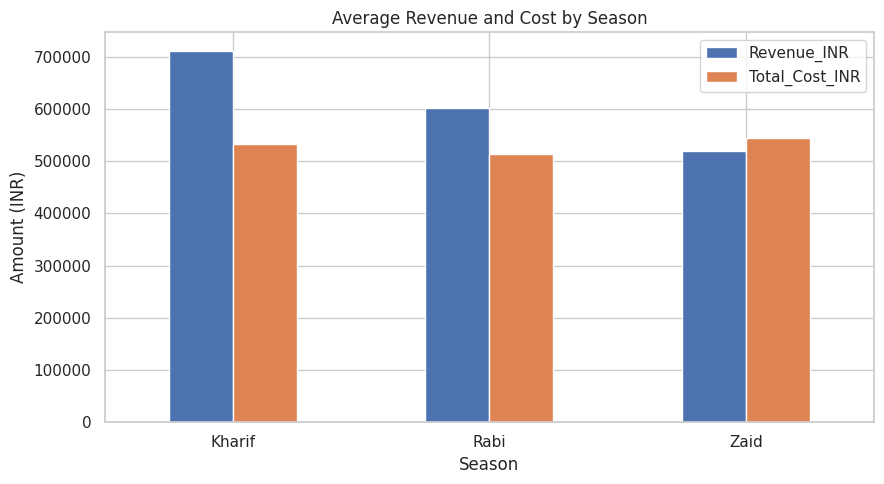

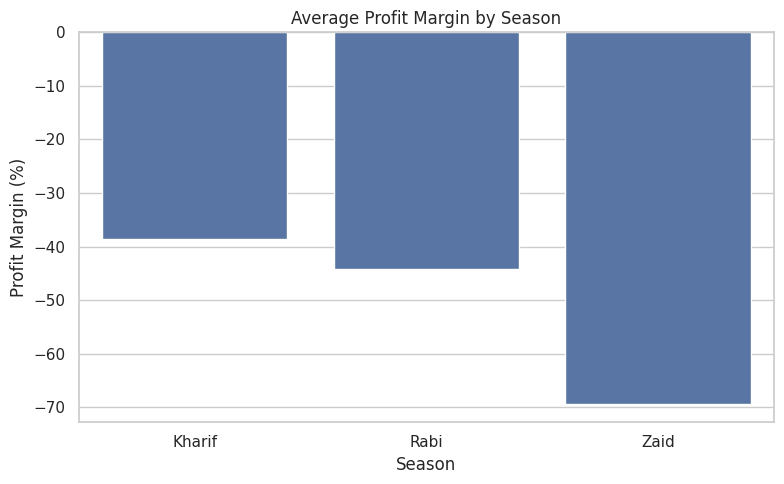


WATER EFFICIENCY


,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.89
Rabi,5.19
Zaid,4.41


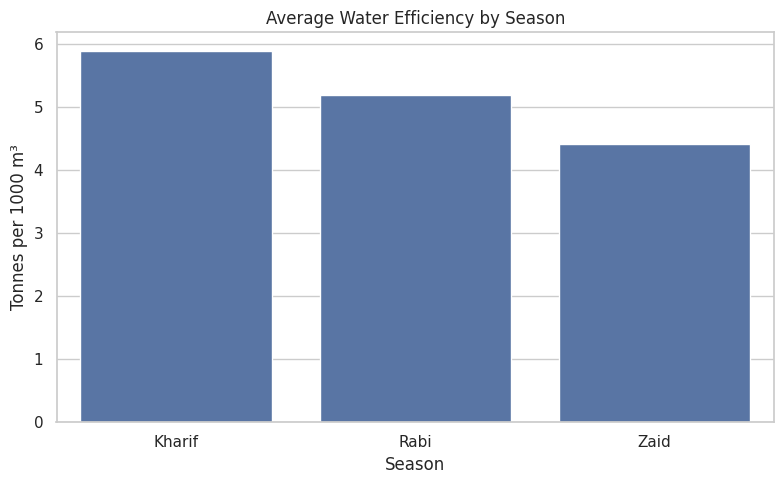


DISEASE AND PEST RISK


,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


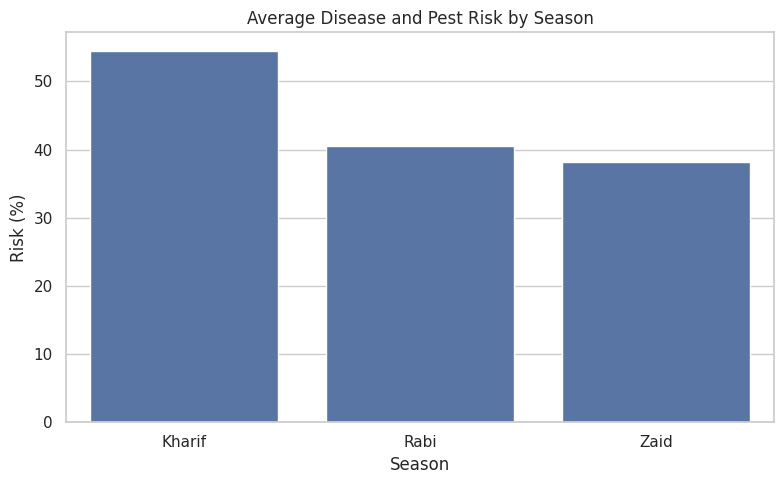

In [15]:
# ============================================================
# CELL 9: ECONOMIC, WATER EFFICIENCY AND DISEASE ANALYSIS
# ============================================================

print("=" * 60)
print("ECONOMIC PERFORMANCE")
print("=" * 60)

economic_summary = df_clean.groupby("Season").agg({
    "Market_Price_INR_Tonne": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Profit_Margin_pct": "mean"
}).round(2)

display(economic_summary)

# ------------------------------------------------------------
# REVENUE VS COST
# ------------------------------------------------------------

revenue_cost = df_clean.groupby("Season")[
    ["Revenue_INR", "Total_Cost_INR"]
].mean()

revenue_cost.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Revenue and Cost by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PROFIT MARGIN
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Profit_Margin_pct",
    estimator="mean",
    errorbar=None
)

plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# WATER EFFICIENCY
# ------------------------------------------------------------

water_efficiency = df_clean.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean().sort_values(
    ascending=False
)

print("\n" + "=" * 60)
print("WATER EFFICIENCY")
print("=" * 60)

display(water_efficiency.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DISEASE AND PEST RISK
# ------------------------------------------------------------

disease_risk = df_clean.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean().sort_values(
    ascending=False
)

print("\n" + "=" * 60)
print("DISEASE AND PEST RISK")
print("=" * 60)

display(disease_risk.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=disease_risk.index,
    y=disease_risk.values
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.tight_layout()
plt.show()

CORRELATION ANALYSIS


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,-0.01,0.01,-0.03,0.01,0.02,1.00,-0.00,0.02,0.00,0.00,-0.00,0.15,0.01,-0.07,0.00,0.01,0.02


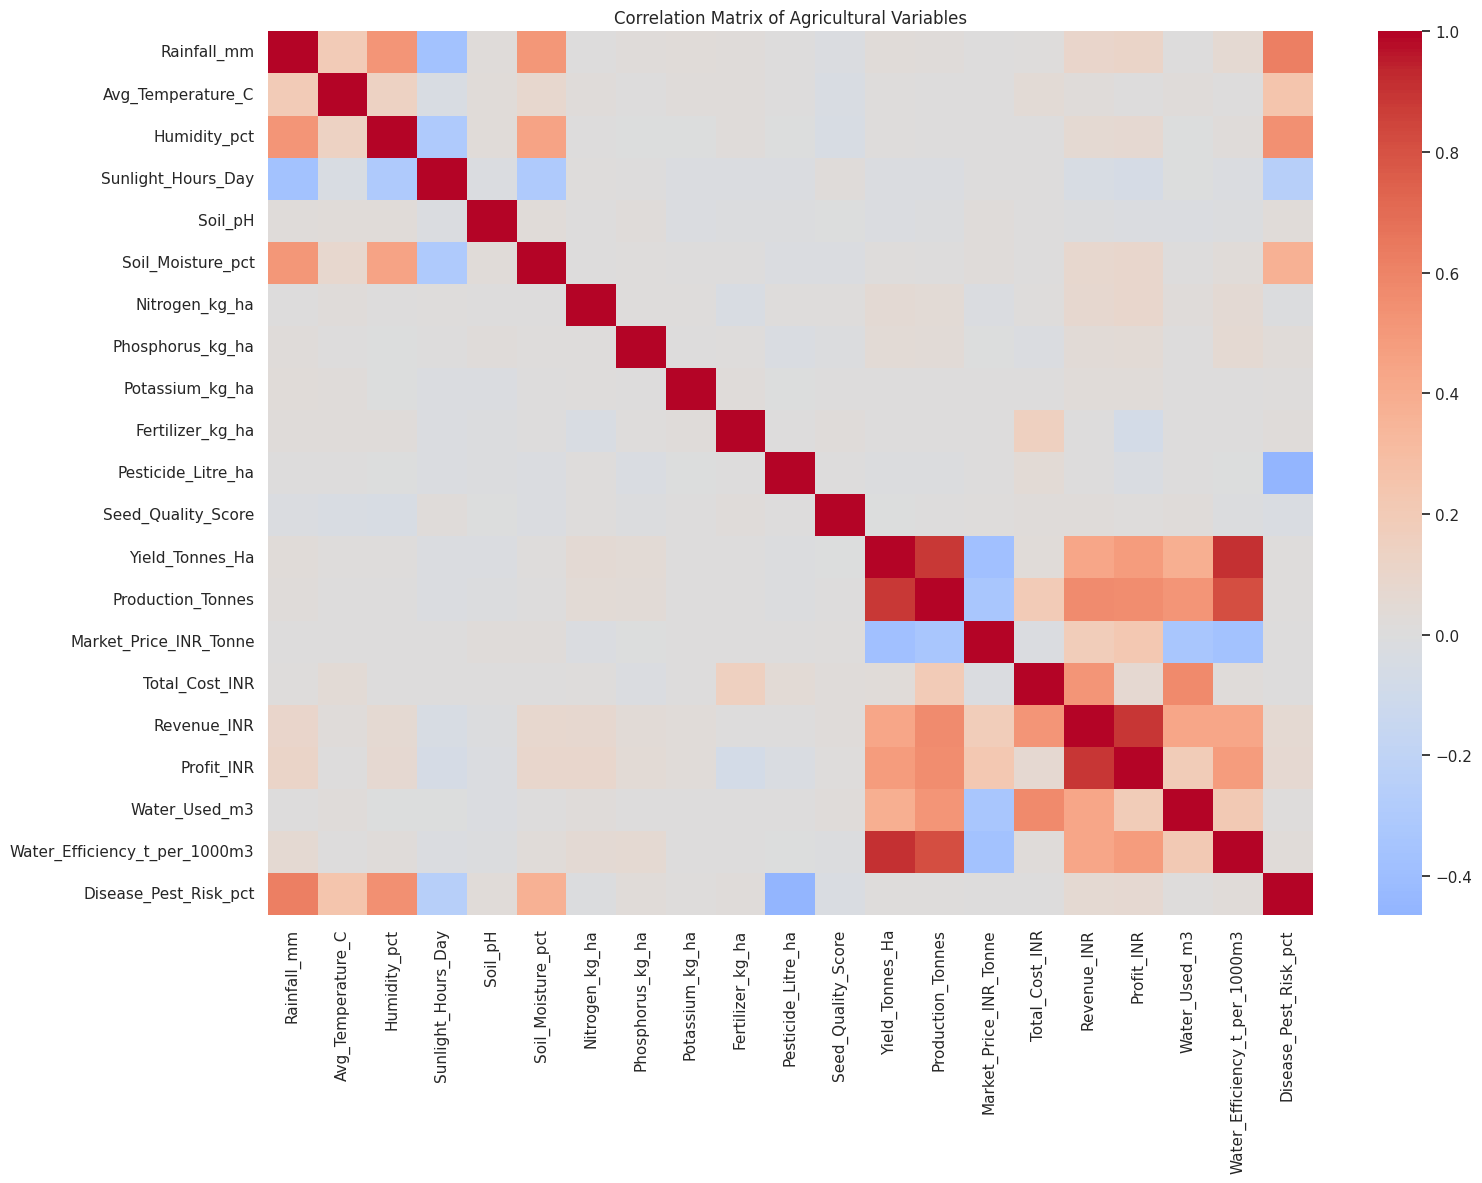


Strongest Relationships with Yield:


,Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Market_Price_INR_Tonne,-0.38
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03



Strongest Relationships with Profit:


,Profit_INR
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Rainfall_mm,0.11
Soil_Moisture_pct,0.09
Nitrogen_kg_ha,0.09
Fertilizer_kg_ha,-0.07


In [16]:
# ============================================================
# CELL 10: CORRELATION ANALYSIS
# ============================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

# Display correlation matrix
display(correlation_matrix.round(2))

# ------------------------------------------------------------
# HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STRONGEST RELATIONSHIPS WITH YIELD
# ------------------------------------------------------------

yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nStrongest Relationships with Yield:")
display(yield_correlations.round(3))

# ------------------------------------------------------------
# STRONGEST RELATIONSHIPS WITH PROFIT
# ------------------------------------------------------------

profit_correlations = (
    correlation_matrix["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nStrongest Relationships with Profit:")
display(profit_correlations.round(3))

STATISTICAL TEST: ONE-WAY ANOVA

ANOVA F-statistic: 1.5439
ANOVA p-value    : 0.21367813841792296

Significance Level (α): 0.05

Conclusion:
There is no statistically significant difference in average agricultural yield among the seasons (p >= 0.05).


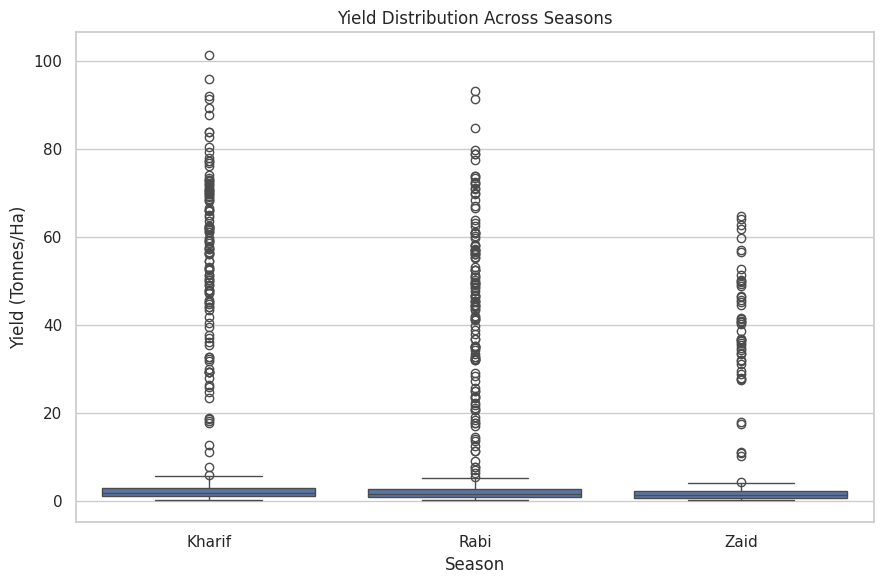

In [17]:
# ============================================================
# CELL 11: STATISTICAL ANALYSIS - ONE-WAY ANOVA
# ============================================================

print("=" * 60)
print("STATISTICAL TEST: ONE-WAY ANOVA")
print("=" * 60)

# Get yield data for each season

season_groups = []

for season in df_clean["Season"].unique():
    values = df_clean[
        df_clean["Season"] == season
    ]["Yield_Tonnes_Ha"]

    season_groups.append(values)

# Perform ANOVA
anova_result = stats.f_oneway(*season_groups)

print("\nANOVA F-statistic:", round(anova_result.statistic, 4))
print("ANOVA p-value    :", anova_result.pvalue)

alpha = 0.05

print("\nSignificance Level (α):", alpha)

if anova_result.pvalue < alpha:
    print(
        "\nConclusion:"
        "\nThere is a statistically significant difference "
        "in average agricultural yield among the seasons "
        "(p < 0.05)."
    )
else:
    print(
        "\nConclusion:"
        "\nThere is no statistically significant difference "
        "in average agricultural yield among the seasons "
        "(p >= 0.05)."
    )

# ------------------------------------------------------------
# YIELD DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# CELL 12: FINAL FINDINGS AND RECOMMENDATIONS
# ============================================================

print("=" * 70)
print("FINAL DATA-DRIVEN FINDINGS")
print("=" * 70)

# ------------------------------------------------------------
# SEASONAL METRICS
# ------------------------------------------------------------

season_yield = (
    df_clean.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

season_profit = (
    df_clean.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

season_water = (
    df_clean.groupby("Season")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

season_risk = (
    df_clean.groupby("Season")[
        "Disease_Pest_Risk_pct"
    ]
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# CROP METRICS
# ------------------------------------------------------------

crop_yield = (
    df_clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

crop_profit = (
    df_clean.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# IRRIGATION
# ------------------------------------------------------------

irrigation_yield = (
    df_clean.groupby("Irrigation_Method")[
        "Yield_Tonnes_Ha"
    ]
    .mean()
    .sort_values(ascending=False)
)

irrigation_water = (
    df_clean.groupby("Irrigation_Method")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# DISPLAY FINDINGS
# ------------------------------------------------------------

print("\n1. SEASONAL YIELD")
print(
    f"Highest average yield: {season_yield.index[0]} "
    f"({season_yield.iloc[0]:.2f} tonnes/ha)"
)

print(
    f"Lowest average yield: {season_yield.index[-1]} "
    f"({season_yield.iloc[-1]:.2f} tonnes/ha)"
)

print("\n2. SEASONAL PROFIT")
print(
    f"Highest average profit: {season_profit.index[0]} "
    f"(₹{season_profit.iloc[0]:,.2f})"
)

print(
    f"Lowest average profit: {season_profit.index[-1]} "
    f"(₹{season_profit.iloc[-1]:,.2f})"
)

print("\n3. WATER EFFICIENCY")
print(
    f"Highest water efficiency: {season_water.index[0]} "
    f"({season_water.iloc[0]:.2f} tonnes/1000 m³)"
)

print("\n4. DISEASE AND PEST RISK")
print(
    f"Highest average risk: {season_risk.index[0]} "
    f"({season_risk.iloc[0]:.2f}%)"
)

print("\n5. TOP CROP BY YIELD")
print(
    f"{crop_yield.index[0]} "
    f"({crop_yield.iloc[0]:.2f} tonnes/ha)"
)

print("\n6. TOP CROP BY PROFIT")
print(
    f"{crop_profit.index[0]} "
    f"(₹{crop_profit.iloc[0]:,.2f})"
)

print("\n7. BEST IRRIGATION METHOD BY YIELD")
print(
    f"{irrigation_yield.index[0]} "
    f"({irrigation_yield.iloc[0]:.2f} tonnes/ha)"
)

print("\n8. BEST IRRIGATION METHOD BY WATER EFFICIENCY")
print(
    f"{irrigation_water.index[0]} "
    f"({irrigation_water.iloc[0]:.2f} tonnes/1000 m³)"
)

# ------------------------------------------------------------
# FINAL SUMMARY TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SEASONAL SUMMARY")
print("=" * 70)

final_summary = df_clean.groupby("Season").agg(
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Production_Tonnes=("Production_Tonnes", "mean"),
    Average_Revenue_INR=("Revenue_INR", "mean"),
    Average_Cost_INR=("Total_Cost_INR", "mean"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    ),
    Average_Disease_Risk=(
        "Disease_Pest_Risk_pct",
        "mean"
    )
).round(2)

display(final_summary)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

df_clean.to_csv(
    "/content/cleaned_seasonal_agriculture_dataset.csv",
    index=False
)

season_performance.to_csv(
    "/content/season_performance.csv"
)

crop_performance.to_csv(
    "/content/crop_performance.csv"
)

state_performance.to_csv(
    "/content/state_performance.csv"
)

economic_summary.to_csv(
    "/content/economic_summary.csv"
)

print("\nAnalysis completed successfully.")
print("Cleaned dataset and major analysis tables have been saved.")

FINAL DATA-DRIVEN FINDINGS

1. SEASONAL YIELD
Highest average yield: Kharif (5.63 tonnes/ha)
Lowest average yield: Zaid (4.64 tonnes/ha)

2. SEASONAL PROFIT
Highest average profit: Kharif (₹178,914.65)
Lowest average profit: Zaid (₹-24,804.82)

3. WATER EFFICIENCY
Highest water efficiency: Kharif (5.89 tonnes/1000 m³)

4. DISEASE AND PEST RISK
Highest average risk: Kharif (54.47%)

5. TOP CROP BY YIELD
Sugarcane (46.64 tonnes/ha)

6. TOP CROP BY PROFIT
Sugarcane (₹817,187.99)

7. BEST IRRIGATION METHOD BY YIELD
Drip (6.58 tonnes/ha)

8. BEST IRRIGATION METHOD BY WATER EFFICIENCY
Rainfed (7.56 tonnes/1000 m³)

FINAL SEASONAL SUMMARY


,Average_Yield_Tonnes_Ha,Average_Production_Tonnes,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Water_Used_m3,Average_Water_Efficiency,Average_Disease_Risk
Season,,,,,,,,
Kharif,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22



Analysis completed successfully.
Cleaned dataset and major analysis tables have been saved.
